# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish simple **benchmarks** to contextualise the results.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch)](#424-hyperparameter-search-definition-gridsearch)
- [Evaluation & Save Utilities](#evaluation--save-utilities)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
    - [Community Area Encoding](#community-area-encoding)
- [Feature Selection](#feature-selection)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [Embed Dimension Search](#embed-dimension-search)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Tuned Deeper — Training](#4212-tuned-deeper--training)
  - [4.2.12 Tuned Deeper — Evaluation](#4212-tuned-deeper--evaluation)
- [4.2.13 Wider Model — Training](#4213-wider-model--training)
  - [4.2.13 Wider Model — Evaluation](#4213-wider-model--evaluation)
- [4.2.14 Hyperparameter Search — Wider Model](#4214-hyperparameter-search--wider-model)
  - [4.2.14 Tuned Wider — Training](#4214-tuned-wider--training)
  - [4.2.14 Tuned Wider — Evaluation](#4214-tuned-wider--evaluation)
- [4.2.15 Visualization: Trip Count Distribution](#4215-visualization-trip-count-distribution)
- [4.2.16 Visualization: Architecture Comparison](#4216-visualization-architecture-comparison)
  - [Learning Curves](#learning-curves)
  - [Statistical Significance — Wilcoxon Signed-Rank](#statistical-significance--wilcoxon-signed-rank)


In [89]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2

# evaluation
import datetime

# model visualization
from torchinfo import summary

# reset working dir
import os
from pathlib import Path


In [90]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [91]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/community_area/demand_ca_2h.parquet")

In [92]:
data

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01 00:00:00,482136,1,residential,7,7,3.750000,864.000000,5.865714,17.671429,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01 00:00:00,482136,2,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01 00:00:00,482136,3,residential,29,28,9.473684,960.655172,5.275862,18.868966,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01 00:00:00,482136,4,residential,5,5,7.500000,770.200000,3.812000,13.288000,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01 00:00:00,482136,5,residential,6,6,11.250000,1131.666667,4.621667,16.415000,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337255,2025-12-31 22:00:00,490894,73,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,0.425947,3.980834,0.405491,0.135164,0.135164,0.000000,0.000000,0.000000,0.000000,0.675819
337256,2025-12-31 22:00:00,490894,74,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,3.559516,1.251690,0.000000,0.000000,0.142409,0.000000,0.000000,0.284818,0.000000,0.427226
337257,2025-12-31 22:00:00,490894,75,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,0.338770,3.515175,0.351464,0.351464,0.468619,0.000000,0.000000,0.000000,0.000000,1.171548
337258,2025-12-31 22:00:00,490894,76,airport,64,64,153.000000,1662.750000,14.605313,37.824219,...,0.296977,1.858189,0.231583,0.868438,0.578958,0.086844,0.000000,0.000000,0.028948,1.794771


## 4.2.1 Data Information

In [93]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# How often does each community area + hour-of-day combination appear?
area_hour_counts = data.groupby(['pickup_community_area', 'hour_of_day']).size()

print(f"\n--- Community area × Hour-of-day ---")
print(f"Unique area × hour combinations : {len(area_hour_counts):>8,}")
print(f"Avg appearances per combo      : {area_hour_counts.mean():>8.1f}x")
print(f"Min appearances                : {area_hour_counts.min():>8,}")
print(f"Max appearances                : {area_hour_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :    337,260
Unique combinations (no time) :    337,260
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :  337,260 combinations

--- Community area × Hour-of-day ---
Unique area × hour combinations :      924
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :  109,880  (32.6%)
Non-zero-demand rows           :  227,380  (67.4%)


In [94]:
data.head()

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,7,7,3.750000,864.000000,5.865714,17.671429,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,29,28,9.473684,960.655172,5.275862,18.868966,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,5,5,7.500000,770.200000,3.812000,13.288000,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,6,6,11.250000,1131.666667,4.621667,16.415000,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747


## 4.2.2 Model Configurations

In [95]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- optimization ---
OPTIMIZER          = "sgd"
LEARNING_RATE      = 5e-5 # (initial LR)
WEIGHT_DECAY       = 0.0     # decoupled L2 (AdamW); per-arch values come from the HP search
BATCH_SIZE         = 1024
MAX_EPOCHS         = 300

# --- loss / output ---
LOSS               = "nb_nll"  # "mse" | "mae" | "poisson_nll" | "nb_nll" (count NLLs: raw-count targets, log-rate output)
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# --- layer defaults ---
HIDDEN_ACTIVATION  = "relu"
WEIGHT_INIT        = "he_normal"

# --- early stopping ---
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# --- data handling ---
SPLIT              = "random"
SCALER_FIT_ON      = "train_only"

# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- reproducibility ---
SEEDS              = (0,)

# --- architectures ---
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

# --- community-area embedding ---
CA_EMBED_DIM       = 16

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    LEARNING_RATE  = LEARNING_RATE,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
    CA_EMBED_DIM   = CA_EMBED_DIM,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}


HP_SEARCH_SEEDS        = SEEDS   # same single seed for hp search and final training
HP_PATIENCE            = 5
BEST_HP                = {}

HP_LR_DECADES  = [2e-5, 5e-5, 8e-5, 2e-4, 5e-4, 8e-4, 2e-3, 5e-3, 8e-3, 2e-2, 5e-2, 8e-2]   # step 1: one representative per decade
HP_WD_DECADES  = [0.0, 5e-4, 5e-3, 5e-2]    # 0.0 = unregularized control
HP_FINE_STEPS  = list(range(1, 10))           # step 2: multipliers inside the winning decade


## 4.2.3 Model Definition

In [96]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def nb_nll_loss(log_mu, y, log_theta):
    """NB2 negative log-likelihood: mean μ = exp(log_mu), Var = μ + μ²/θ, θ = exp(log_theta)."""
    theta   = torch.exp(log_theta)
    mu      = torch.exp(log_mu)
    log_t_m = torch.log(theta + mu)
    ll = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1.0)
          + theta * (log_theta - log_t_m)
          + y     * (log_mu    - log_t_m))
    return -ll.mean()


class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width, n_ca, embed_dim):
        super().__init__()
        self.ca_embed = nn.Embedding(n_ca, embed_dim)
        nn.init.normal_(self.ca_embed.weight, std=0.01)

        layers = []
        in_dim = input_dim + embed_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.ReLU()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") not in ("poisson_nll", "nb_nll"):
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(μ), consumed by the Poisson/NB NLL
        self.net = nn.Sequential(*layers)

        if getattr(config, "LOSS", "mse") == "nb_nll":
            # NB2 dispersion, trained jointly with the network weights
            self.log_theta = nn.Parameter(torch.zeros(()))

    def forward(self, x, ca_idx):
        emb = self.ca_embed(ca_idx)           # (batch, embed_dim)
        x   = torch.cat([x, emb], dim=-1)     # (batch, input_dim + embed_dim)
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                ca_train, ca_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None, weight_decay=None,
                embed_dim=None, epoch_cb=None, test_data=None):
    if seed is not None:
        set_seed(seed)
    n_layers, width = arch
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    _embed_dim = embed_dim if embed_dim is not None else config.CA_EMBED_DIM
    model = DemandBaseline(X_train.shape[1], n_layers, width, N_CA, _embed_dim).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    elif _loss_name == "poisson_nll":
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # model outputs log-rate; exp() applied internally
    elif _loss_name == "nb_nll":
        def loss_fn(log_mu, y):   # model outputs log-mean; dispersion θ trained jointly
            return nb_nll_loss(log_mu, y, model.log_theta)
    else:
        raise ValueError(f"unknown config.LOSS: {_loss_name!r}")

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _wd             = weight_decay if weight_decay is not None else getattr(config, 'WEIGHT_DECAY', 0.0)
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9, weight_decay=_wd)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr, weight_decay=_wd)
    else:
        # AdamW = decoupled weight decay; plain Adam's L2 gets rescaled by the adaptive LR
        optimizer = torch.optim.AdamW(model.parameters(), lr=_lr, weight_decay=_wd)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train, dtype=torch.float32),
            torch.as_tensor(ca_train, dtype=torch.long),
            torch.as_tensor(y_train, dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t = torch.as_tensor(X_val, dtype=torch.float32).to(device)
    ca_val_t = torch.as_tensor(ca_val, dtype=torch.long).to(device)
    y_val_t = torch.as_tensor(y_val, dtype=torch.float32).to(device)
    if test_data is not None:   # optional (X, y, group) on the training scale — monitoring only
        X_test_t = torch.as_tensor(test_data[0], dtype=torch.float32).to(device)
        y_test_t = torch.as_tensor(test_data[1], dtype=torch.float32).to(device)
        g_test_t = torch.as_tensor(test_data[2], dtype=torch.long).to(device)
    history = {"train": [], "val": [], "test": []}

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        for xb, cb, yb in train_dl:
            xb, cb, yb = xb.to(device), cb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb, cb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t, ca_val_t), y_val_t).item()
            if test_data is not None:
                history["test"].append(loss_fn(model(X_test_t, g_test_t), y_test_t).item())
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if not np.isfinite(val_loss):
            if verbose:
                print(f"  ↳ diverged (val_loss={val_loss}) at epoch {epoch + 1}")
            break

        if epoch_cb is not None:
            epoch_cb(epoch, val_loss)   # hp-search hook; may raise to abort the run

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    # else: run diverged before any improvement; best_val stays inf so the
    # HP search ranks the combo last instead of crashing
    model.history = history   # per-epoch losses for the learning-curve plots
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch using Optuna)

Two-step search→fine grid search (Optuna `GridSampler`):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, three representative values
   per decade to locate the best decade of the learning rate for the finer hyperparameter search.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade from step 1.
    - e.g. decade step 1 identified 1e-3 to be the best decade, then [1e-3, 2e-3, ..., 9e-3] are evaluated to find the best LR.

This way only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result.

In [97]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility (Optuna GridSampler)  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

optuna.logging.set_verbosity(optuna.logging.WARNING)


def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  ca_train, ca_val,
                  device='cpu',
                  lr_candidates=None, wd_candidates=None):
    """Optuna grid search (GridSampler) over lr and weight decay.

    Every lr × wd combination from the candidate lists is evaluated exactly
    once, so this is a true exhaustive grid search; the median pruner aborts
    combinations whose validation loss is clearly worse than the running
    median. Each trial trains one model per seed in HP_SEARCH_SEEDS and is
    scored by the mean validation loss, so the search is reproducible.
    """
    lr_candidates = lr_candidates or HP_LR_DECADES
    wd_candidates = wd_candidates if wd_candidates is not None else HP_WD_DECADES
    arch_label    = ARCH_NAMES.get(arch, str(arch))
    search_space  = {'lr': list(lr_candidates), 'weight_decay': list(wd_candidates)}
    n_trials      = len(lr_candidates) * len(wd_candidates)

    def objective(trial):
        lr = trial.suggest_categorical('lr', lr_candidates)
        wd = trial.suggest_categorical('weight_decay', wd_candidates)

        def epoch_cb(epoch, val_loss):
            # pruning is judged on the first seed's run only
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        val_losses = []
        for j, seed in enumerate(HP_SEARCH_SEEDS):
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                ca_train, ca_val,
                seed=seed, device=device, verbose=False,
                lr=lr, weight_decay=wd, patience=HP_PATIENCE,
                epoch_cb=epoch_cb if j == 0 else None,
            )
            val_losses.append(val_loss)
        return float(np.mean(val_losses))

    print(f'HP Search — {arch_label}  |  grid {len(lr_candidates)}×{len(wd_candidates)}'
          f' = {n_trials} combos  |  seeds={HP_SEARCH_SEEDS}  |  patience={HP_PATIENCE}\n')
    print(f"{'#':>4}  {'lr':>10}  {'wd':>10}  {'mean val':>10}  state")
    print('-' * 50)

    def log_trial(study, trial):
        wd  = trial.params.get('weight_decay', 0.0)
        val = trial.value if trial.value is not None else float('nan')
        print(f"{trial.number + 1:>4}  {trial.params['lr']:>10.2e}  {wd:>10.2e}"
              f"  {val:>10.4f}  {trial.state.name.lower()}")

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.GridSampler(search_space, seed=HP_SEARCH_SEEDS[0]),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, callbacks=[log_trial])

    complete = [t for t in study.trials
                if t.state == optuna.trial.TrialState.COMPLETE]
    print('\n--- Top 5 ---')
    for t in sorted(complete, key=lambda t: t.value)[:5]:
        print(f"  lr={t.params['lr']:.2e}"
              f"  wd={t.params.get('weight_decay', 0.0):.2e}"
              f"  val_loss={t.value:.4f}")

    p = study.best_trial.params
    BEST_HP[arch] = {'lr': float(p['lr']),
                     'weight_decay': float(p.get('weight_decay', 0.0))}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]


def fine_candidates(best, steps=None):
    """Fine grid inside the decade of `best`, e.g. 5e-4 -> [2e-4, 4e-4, 5e-4, 6e-4, 8e-4].

    best = 0.0 (unregularized weight decay) has no decade and stays [0.0].
    """
    if best == 0.0:
        return [0.0]
    steps = steps or HP_FINE_STEPS
    decade = 10.0 ** int(np.floor(np.log10(best)))
    return [float(f'{s * decade:.0e}') for s in steps]


def run_hp_search_2step(arch, X_train, y_train, X_val, y_val,
                        ca_train, ca_val, device='cpu',
                        lr_decades=None, wd_decades=None):
    """Coarse-to-fine grid search: step 1 locates the best order of magnitude
    for lr and weight decay on a decade grid, step 2 runs a finer grid
    restricted to the winning decades. Both steps are exhaustive grids, so
    only rough orders of magnitude need to be known upfront."""
    lr_decades = lr_decades or HP_LR_DECADES
    wd_decades = wd_decades if wd_decades is not None else HP_WD_DECADES
    arch_label = ARCH_NAMES.get(arch, str(arch))

    print(f'=== Step 1/2 — decade grid ({arch_label}) ===\n')
    coarse = run_hp_search(arch, X_train, y_train, X_val, y_val,
                           ca_train, ca_val, device=device,
                           lr_candidates=lr_decades, wd_candidates=wd_decades)

    # keep the coarse winners in the fine grid so step 2 can never end up worse
    lr_fine = sorted(set(fine_candidates(coarse['lr']) + [coarse['lr']]))
    wd_fine = sorted(set(fine_candidates(coarse['weight_decay']) + [coarse['weight_decay']]))
    print(f'\n=== Step 2/2 — fine grid in winning decades ({arch_label}) ===')
    print(f'lr candidates: {lr_fine}')
    print(f'wd candidates: {wd_fine}\n')
    # overwrites BEST_HP[arch] with the fine-grid winner
    return run_hp_search(arch, X_train, y_train, X_val, y_val,
                         ca_train, ca_val, device=device,
                         lr_candidates=lr_fine, wd_candidates=wd_fine)


## Evaluation & Save Utilities
Shared helpers functions: `evaluate_models` computes the test-set metrics for the models and returns the result rows, `save_results` appends them to the results CSV.

In [98]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Evaluation Utility                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def evaluate_models(arch, models, train_losses, val_losses,
                    X_test, y_test, ca_test,
                    device="cpu", label=None, model_name=None,
                    hp=None, show_weight_stats=False):
    """Evaluate the per-seed models of one architecture on the held-out test set.

    hp    : optional {"lr", "weight_decay"} dict (e.g. BEST_HP[arch]);
            defaults to the shared config values.
    Returns the run_results rows for save_results().
    """
    n_layers, width = arch
    label      = label      or ARCH_NAMES.get(arch, "model").capitalize()
    model_name = model_name or ARCH_NAMES.get(arch, "unknown")
    lr = hp["lr"] if hp else config.LEARNING_RATE
    wd = hp.get("weight_decay", 0.0) if hp else getattr(config, "WEIGHT_DECAY", 0.0)

    X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
    ca_test_t  = torch.as_tensor(ca_test,  dtype=torch.long).to(device)

    run_results = []
    r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
    mape_scores = []
    r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
    correct_zero_counts, false_zero_counts = [], []
    pred_min_scores, pred_max_scores = [], []
    test_losses = []

    zero_demand_count = int((y_test == 0).sum())
    zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
    mean_actual       = float(y_test.mean())
    ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

    y_test_log  = np.log1p(y_test)
    mean_log    = float(y_test_log.mean())
    ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

    print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
    print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

    for i, (seed, model) in enumerate(zip(SEEDS, models)):
        model.eval()

        if show_weight_stats:
            print(f"  seed={seed} layer weight stats:")
            for name, param in model.named_parameters():
                if "weight" in name:
                    w = param.detach().cpu().numpy()
                    print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                          f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

        with torch.no_grad():
            preds_raw = model(X_test_t, ca_test_t).cpu().numpy().flatten()
        preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
        preds_log = np.log1p(preds)
        pred_min, pred_max = float(preds.min()), float(preds.max())

        mae   = float(np.mean(np.abs(preds - y_test)))
        rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
        nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
        r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
        nz    = y_test > 0
        mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))

        mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
        rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
        nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
        r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

        zero_actual  = (y_test == 0)
        zero_pred    = (preds < 0.5)
        correct_zero = int(np.sum(zero_actual & zero_pred))
        false_zero   = int(np.sum(~zero_actual & zero_pred))

        r2_scores.append(r2);         mae_scores.append(mae)
        rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
        mape_scores.append(mape)
        r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
        rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
        correct_zero_counts.append(correct_zero)
        false_zero_counts.append(false_zero)
        pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
        # test loss under the training criterion, so train/val/test are comparable
        _y_target = y_test if IS_POISSON else y_test_log
        if config.LOSS == "mae":
            _test_loss = float(np.mean(np.abs(preds_raw - _y_target)))
        elif config.LOSS == "mse":
            _test_loss = float(np.mean((preds_raw - _y_target) ** 2))
        elif config.LOSS == "poisson_nll":
            _test_loss = float(np.mean(np.exp(preds_raw) - _y_target * preds_raw))
        else:  # nb_nll — evaluate with the model's trained dispersion
            _test_loss = float(nb_nll_loss(torch.as_tensor(preds_raw, dtype=torch.float32),
                                           torch.as_tensor(_y_target, dtype=torch.float32),
                                           model.log_theta.detach().cpu()))
        test_losses.append(_test_loss)

        print(f"  seed={seed}"
              f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%"
              f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
              f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

        run_results.append({
            "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
            "training_loss"     : config.LOSS,
            "model"             : model_name,
            "n_layers"          : n_layers,
            "width"             : width,
            "learning_rate"     : lr,
            "weight_decay"      : wd,
            "batch_size"        : BATCH_SIZE,
            "seed"              : seed,
            "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
            "val_loss"          : val_losses[i],
            "zero_demand_count" : zero_demand_count,
            "mean_actual"       : round(mean_actual, 6),
            "r2"                : round(r2,       6),
            "mae"               : round(mae,      6),
            "rmse"              : round(rmse,     6),
            "nrmse"             : round(nrmse,    6),
            "mape"              : round(mape,     6),
            "r2_log"            : round(r2_log,   6),
            "mae_log"           : round(mae_log,  6),
            "rmse_log"          : round(rmse_log, 6),
            "nrmse_log"         : round(nrmse_log,6),
            "correct_zero"      : correct_zero,
            "false_zero"        : false_zero,
            "pred_min"          : round(pred_min, 6),
            "pred_max"          : round(pred_max, 6),
        })

    print(f"\n--- original scale ---")
    print(f"{label}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
    print(f"{label}  MAPE  : {np.mean(mape_scores):.2f}% ± {np.std(mape_scores):.2f}%  (non-zero actuals only)")
    print(f"\n--- zero-demand ---")
    print(f"{label}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
    print(f"{label}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

    print(f"\n--- prediction range (raw scale) ---")
    print(f"{label}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
    print(f"{label}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

    print(f"\n--- overfitting check ({config.LOSS}, {'raw counts' if IS_POISSON else 'log1p scale'}) ---")
    print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
    for _s, _tr, _vl, _tl in zip(SEEDS, train_losses, val_losses, test_losses):
        print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
    if len(SEEDS) > 1:
        print(f"  {'mean':<8}  {np.mean(train_losses):>8.4f}  {np.mean(val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

    return run_results

In [99]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results Utility                    #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_2h.csv"

def save_results(run_results, results_path=RESULTS_PATH):
    """Append run_results rows to the results CSV (created on first use)."""
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    results_df = pd.DataFrame(run_results)

    if os.path.exists(results_path):
        existing_df = pd.read_csv(results_path)
        combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
        combined_df.to_csv(results_path, index=False)
        print(f"Appended {len(results_df)} rows to {results_path} ({combined_df.shape[1]} columns)")
    else:
        results_df.to_csv(results_path, index=False)
        print(f"Created {results_path} with {len(results_df)} rows")

    print(pd.read_csv(results_path).tail(len(results_df)).to_string(index=False))
    return results_df

## 4.2.5 Visualization: Model Architecture

The values below are illustrative (schematic), not a specific record.

```
One row of raw data  —  one community area in one 2 h bucket
┌─────────────────────────┬───────────────────────────────────┬─────────────┐
│  pickup_community_area  │ is_weekend, month_sin, area_km2,  │ trip_count  │
│            8            │    1,       0.50,     36.4, …     │      5      │
└────────────┬────────────┴─────────────────┬─────────────────┴──────┬──────┘
             │                              │                        │
             ▼                              ▼                        ▼
         ca_vocab                    StandardScaler             np.log1p(y)
             8                   [1.59, 0.40, -0.51, …]            1.79
            → 7                (n_num dims, fit on train)    (training target)
             │                              │
             ▼                              │
 Embedding table                            │
 (N_CA rows × CA_EMBED_DIM)                 │
 row 7: [0.12, -0.31, …]                    │
             │                              │
             └──────────────┬───────────────┘
                            ▼
                    torch.cat(x, emb)
             [0.12, -0.31, …, 1.59, 0.40, …]
               (CA_EMBED_DIM + n_num dims)
                            │
                            ▼
             ┌─────────────────────────────┐
             │  Linear(dim → 64)           │
             │  ReLU                       │   ← 2 blocks × 64   (baseline)
             │  Linear(64 → 64)            │      2 blocks × 256 (wider)
             │  ReLU                       │      8 blocks × 64  (deeper)
             │  Linear(64 → 1)             │
             │  Softplus                   │   ← keeps the log1p output ≥ 0
             └─────────────────────────────┘
                            │
                            ▼
            ŷ_log   (predicted log1p demand)
                            │
                            ▼  np.expm1(ŷ_log) ← evaluation only, never in the loss
             ŷ   (predicted trip count, ≥ 0)
```

**Target scale.** The network is trained on `log1p(trip_count)`, so both the `Softplus` output and
the training criterion (`config.LOSS = "mae"`) live on the log1p scale — `Softplus` is what keeps
the back-transformed prediction non-negative. Raw trip counts reappear only at evaluation time,
where `expm1` inverts the transform before evaluation metrics are computed.

**Community area embedding.** The table holds one row per community area seen in training
plus one reserved *unknown* row for community areas that appear only in val/test. It
starts with near-zero weights and is updated by backprop alongside all other parameters, so the
network learns which community areas behave similarly. `CA_EMBED_DIM` is not fixed upfront: the embed
dimension search below selects it from `[8, 16, 32]`.

## 4.2.6 Train / Val / Test Split

We split rows chronologically into **70 % train / 15 % val / 15 % test** using
`train_test_split`.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [100]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :   236,082 rows
Val   :    50,589 rows
Test  :    50,589 rows


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.

We split the features into LEAKAGE, CYCLIC, ID and TARGET columns to have a better overview of how the FEATURE columns are composed. All three column types: LEAKAGE, RAW_CYCLIC, ID are removed since they are not relevant for our models.
- LEAKAGE contain the columns that need to be removed, either because they leak undesired information into our models (e.g. idle_time, avg_tip etc.), or because they do not add any informational value or even harm the model
- RAW_CYCLIC are the raw temporal columns that have not been transformed (transformed columns are included in FEATURE column)
- ID contains columns we need to remove, e.g. bucket_index or pickup_community_area


#### Community Area Encoding

Community area identity is encoded with a **learnable embedding** (`nn.Embedding`),
trained jointly with the network.

In [101]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
]
RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_community_area']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val   = scaler.transform(val_data[FEATURE_COLS].values)
X_test  = scaler.transform(test_data[FEATURE_COLS].values)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

# community-area embedding indices — vocabulary built from the training set only;
# areas unseen in training map to a reserved "unknown" index
ca_vocab = {a: i for i, a in enumerate(sorted(train_data['pickup_community_area'].unique()))}
UNK_CA   = len(ca_vocab)
N_CA     = len(ca_vocab) + 1   # +1 for the unknown bucket

ca_train = train_data['pickup_community_area'].map(ca_vocab).astype(int).values
ca_val   = val_data['pickup_community_area'].map(ca_vocab).fillna(UNK_CA).astype(int).values
ca_test  = test_data['pickup_community_area'].map(ca_vocab).fillna(UNK_CA).astype(int).values

print(f"Unique community areas (train) : {len(ca_vocab)}  |  embed dim : {CA_EMBED_DIM}")
print(f"Unseen areas  val: {(ca_val == UNK_CA).sum()}   test: {(ca_test == UNK_CA).sum()}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")

Numeric features (29): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'is_day', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'train_station_per_km2', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'universities_per_km2', 'attractions_per_km2', 'poi_density_total_per_km2']
Target scale : raw counts (count NLL)
Unique community areas (train) : 77  |  embed dim : 16
Unseen areas  val: 0   test: 0

X_train : (236082, 29)   y_train : (236082,)
X_val   : (50589, 29)     y_val   : (50589,)
X_test  : (50589, 29)    y_test  : (50589,)


## Feature Selection

We base our decision of feature selection on two selection methods:

1. correlation matrix
2. model-based feature importance

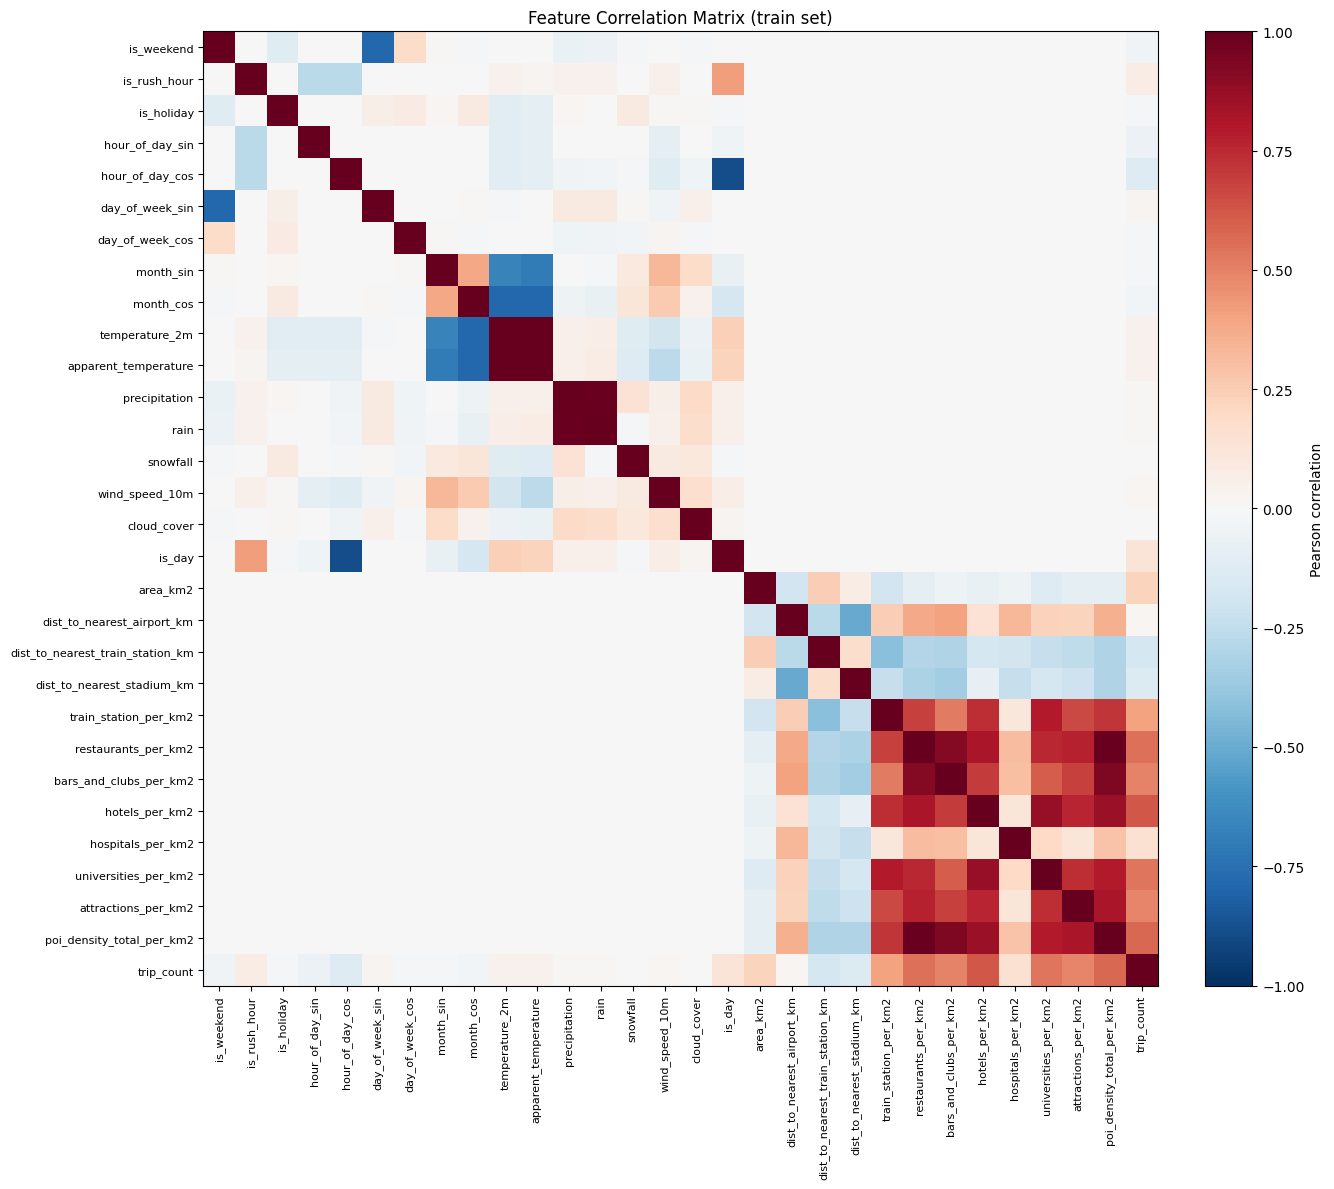

Feature pairs with |correlation| >= 0.8:
  temperature_2m                      vs apparent_temperature                 r=+0.994
  restaurants_per_km2                 vs poi_density_total_per_km2            r=+0.991
  precipitation                       vs rain                                 r=+0.988
  bars_and_clubs_per_km2              vs poi_density_total_per_km2            r=+0.930
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.921
  hour_of_day_cos                     vs is_day                               r=-0.889
  hotels_per_km2                      vs universities_per_km2                 r=+0.871
  hotels_per_km2                      vs poi_density_total_per_km2            r=+0.866
  restaurants_per_km2                 vs hotels_per_km2                       r=+0.820
  attractions_per_km2                 vs poi_density_total_per_km2            r=+0.817


In [102]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")

In [105]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")

                         feature  rf_importance  perm_importance  perm_importance_std
                  hotels_per_km2       0.414511         1.174578             0.006304
                 hour_of_day_sin       0.098296         0.228994             0.003442
                          is_day       0.135009         0.212717             0.003910
      dist_to_nearest_airport_km       0.081254         0.130816             0.001477
                 hour_of_day_cos       0.050954         0.091232             0.000922
                        area_km2       0.076333         0.090357             0.001149
                 day_of_week_sin       0.029269         0.053059             0.001242
      dist_to_nearest_stadium_km       0.020149         0.034536             0.000228
                      is_weekend       0.015944         0.020236             0.000591
                       month_cos       0.010345         0.017746             0.000436
                 day_of_week_cos       0.006759       

### **Final drop list**

*Applied identically across all community-area resolutions (1h / 2h / 6h / 24h) so the four models share one feature space.*

- `is_rush_hour`
- `temperature_2m`
- `apparent_temperature`
- `rain`
- `precipitation`
- `wind_speed_10m`
- `cloud_cover`
- `snowfall`
- `is_day`
- `poi_density_total_per_km2`
- `universities_per_km2`
- `restaurants_per_km2`

#### **Retained (17)**

- Temporal: `is_weekend`, `is_holiday`, `hour_of_day_sin`, `hour_of_day_cos`, `day_of_week_sin`, `day_of_week_cos`, `month_sin`, `month_cos`
- Distance: `dist_to_nearest_airport_km`, `dist_to_nearest_train_station_km`, `dist_to_nearest_stadium_km`
- POI density: `hotels_per_km2`, `bars_and_clubs_per_km2`, `attractions_per_km2`, `train_station_per_km2`, `hospitals_per_km2`
- Area: `area_km2`

#### **Cyclic hour encoding**

- `hour_of_day_sin`, `hour_of_day_cos` are the strongest predictors at fine resolution (permutation importance ≈ 0.26 / 0.12 at 1h), so they are kept for every resolution. At 24h there is exactly one row per area per day, so they are constant — inert after scaling — but retained so the feature space is identical across resolutions.
- `is_rush_hour` — dropped: weak (perm ≈ 0.007) and r=−0.82 with `hour_of_day_sin`, i.e. redundant with the cyclic encoding; constant at 24h.

#### **Weather (dropped as a block)**

- Manual testing showed removing weather improved results across the board, and the model-based importances agree (permutation importance ≈ 0.0002 – 0.007). `temperature_2m`/`apparent_temperature` (r=0.99) and `rain`/`precipitation` (r=0.99) are additionally mutually redundant.

#### **Season proxy**

- `is_day` — r=−0.96 with `month_cos` (and with `hour_of_day_cos` at sub-daily resolution); a daylight/season proxy, dropped in favour of the direct cyclic encodings.

#### **POI density cluster (r ≥ 0.8)**

- The density columns are mutually collinear (`restaurants` r=0.99 with `poi_density_total`, `bars_and_clubs` 0.93, `hotels` 0.87, `attractions` 0.82; `hotels` r=0.87 with `universities`). For community areas `hotels_per_km2` is by far the strongest POI signal (permutation importance ≈ 1.28), so we resolve the cluster by keeping the components:
    - Keep `hotels_per_km2`, `bars_and_clubs_per_km2`, `attractions_per_km2` — each carries more signal than the columns we drop
    - Drop `poi_density_total_per_km2` (linear aggregate of the components), `universities_per_km2` (r=0.87 with kept `hotels`), and `restaurants_per_km2` (r=0.92 with kept `bars_and_clubs`, lowest importance of the cluster)
    - `train_station_per_km2` and `hospitals_per_km2` are not in any r ≥ 0.8 pair, so they are retained as independent density signals
    - Note: RF importance is split across the correlated group anyway (impurity importance dilutes across collinear features), so the aggregate's rank is not evidence it is uniquely informative

In [137]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Selection.                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    # trip-derived aggregates from the same time bucket -> target leakage
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
]

# Non-leakage columns we deliberately drop, based on the two selection cells
# above (correlation matrix + model-based / permutation importance).
# The SAME set is used for every CA temporal resolution (1h / 2h / 6h / 24h)
# so all four models share one feature space.
DROP_COLS = [
    'is_rush_hour',                              # redundant with the cyclic hour encoding (r=-0.82 with hour_of_day_sin); constant at 24h
    # weather: negligible importance and hurts CV (see manual-testing note)
    'temperature_2m', 'apparent_temperature',   # r=+0.99 with each other
    'rain', 'precipitation',                     # r=+0.99 with each other
    'wind_speed_10m', 'cloud_cover', 'snowfall',
    'is_day',                                    # r=-0.96 with month_cos (season / daylight proxy)
    # redundant POI density: |r| >= 0.8 with a more important feature we keep (hotels-led for community areas)
    'poi_density_total_per_km2',                 # linear aggregate of the POI components we keep
    'universities_per_km2',                      # r=+0.87 with hotels_per_km2
    'restaurants_per_km2',                       # r=+0.92 with bars_and_clubs_per_km2; lowest perm importance of the cluster
]

RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_community_area']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + DROP_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val   = scaler.transform(val_data[FEATURE_COLS].values)
X_test  = scaler.transform(test_data[FEATURE_COLS].values)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

# community-area embedding indices — vocabulary built from the training set only;
# areas unseen in training map to a reserved "unknown" index
ca_vocab = {h: i for i, h in enumerate(sorted(train_data['pickup_community_area'].unique()))}
UNK_CA   = len(ca_vocab)
N_CA     = len(ca_vocab) + 1   # +1 for the unknown bucket

ca_train = train_data['pickup_community_area'].map(ca_vocab).astype(int).values
ca_val   = val_data['pickup_community_area'].map(ca_vocab).fillna(UNK_CA).astype(int).values
ca_test  = test_data['pickup_community_area'].map(ca_vocab).fillna(UNK_CA).astype(int).values

print(f"Unique community areas (train) : {len(ca_vocab)}  |  embed dim : {CA_EMBED_DIM}")
print(f"Unseen areas  val: {(ca_val == UNK_CA).sum()}   test: {(ca_test == UNK_CA).sum()}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")


Numeric features (18): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'attractions_per_km2']
Target scale : raw counts (count NLL)
Unique community areas (train) : 77  |  embed dim : 32
Unseen areas  val: 0   test: 0

X_train : (236082, 18)   y_train : (236082,)
X_val   : (50589, 18)     y_val   : (50589,)
X_test  : (50589, 18)    y_test  : (50589,)


## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each community area × hour-of-day pair, predict the mean `trip_count` observed in the training split. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat the benchmark models is not adding value for our business client. In that case the decision is fixed: the model should not be implemented and the benchmark should be chosen as their prediction model.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [106]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    nz    = y_test > 0
    mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6), mape=round(mape, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_community_area', 'hour_of_day'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_community_area', 'hour_of_day']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_community_area', 'hour_of_day'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (area × hour)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 19,114 / 50,589 (37.8%)
Mean actual test demand : 15.0592

Historical mean (area × hour)        R²=0.8254  MAE=6.5426  RMSE=26.9527  NRMSE=1.7898  MAPE=78.7%
Ridge regression                     R²=0.5645  MAE=14.3245  RMSE=42.5635  NRMSE=2.8264  MAPE=408.5%


## Embed Dimension Search

Since `embed_dim` is independent of architecture depth and width, we search it once on
the baseline and fix the winner for all three models.

Candidates: `[8, 16, 32]` — 3 runs total (with early stopping).

In [107]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Embed Dimension Search                  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

EMBED_CANDIDATES = [8, 16, 32]

print(f"Embed search — ARCH_BASELINE, seed={HP_SEARCH_SEEDS[0]}, patience={HP_PATIENCE}\n")
embed_results = []
for emb in EMBED_CANDIDATES:
    _, val_loss, _ = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=HP_SEARCH_SEEDS[0], device=device, verbose=False,
        lr=config.LEARNING_RATE, embed_dim=emb, patience=HP_PATIENCE,
    )
    embed_results.append((emb, val_loss))
    print(f"  embed_dim={emb:>3}  val_loss={val_loss:.4f}")

best_embed_dim = min(embed_results, key=lambda x: x[1])[0]
CA_EMBED_DIM        = best_embed_dim
config.CA_EMBED_DIM = best_embed_dim
print(f"\nBest embed_dim: {CA_EMBED_DIM}  →  set as global CA_EMBED_DIM")


Embed search — ARCH_BASELINE, seed=0, patience=5

  embed_dim=  8  val_loss=2.0501
  embed_dim= 16  val_loss=2.0213
  embed_dim= 32  val_loss=2.0014

Best embed_dim: 32  →  set as global CA_EMBED_DIM


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` and report
the validation loss.


In [108]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width, N_CA, CA_EMBED_DIM)
x_dummy   = torch.zeros(1, input_dim)
c_dummy   = torch.zeros(1, dtype=torch.long)
summary(viz_model, input_data=(x_dummy, c_dummy), col_names=["input_size", "output_size", "num_params"], verbose=1)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 29]                   [1]                       1
├─Embedding: 1-1                         [1]                       [1, 32]                   2,496
├─Sequential: 1-2                        [1, 61]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 61]                   [1, 64]                   3,968
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 10,690
Trainable params: 10,690
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (M

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 29]                   [1]                       1
├─Embedding: 1-1                         [1]                       [1, 32]                   2,496
├─Sequential: 1-2                        [1, 61]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 61]                   [1, 64]                   3,968
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 10,690
Trainable params: 10,690
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (M

In [138]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

Device: cpu

Epoch   1/300
  loss: 3.5479  val_loss: 2.7631 ✓
Epoch   2/300
  loss: 2.7548  val_loss: 2.6607 ✓
Epoch   3/300
  loss: 2.6923  val_loss: 2.6073 ✓
Epoch   4/300
  loss: 2.6471  val_loss: 2.5685 ✓
Epoch   5/300
  loss: 2.6126  val_loss: 2.5390 ✓
Epoch   6/300
  loss: 2.5854  val_loss: 2.5145 ✓
Epoch   7/300
  loss: 2.5634  val_loss: 2.4938 ✓
Epoch   8/300
  loss: 2.5452  val_loss: 2.4771 ✓
Epoch   9/300
  loss: 2.5300  val_loss: 2.4627 ✓
Epoch  10/300
  loss: 2.5178  val_loss: 2.4504 ✓
Epoch  11/300
  loss: 2.5071  val_loss: 2.4397 ✓
Epoch  12/300
  loss: 2.4979  val_loss: 2.4305 ✓
Epoch  13/300
  loss: 2.4900  val_loss: 2.4223 ✓
Epoch  14/300
  loss: 2.4832  val_loss: 2.4154 ✓
Epoch  15/300
  loss: 2.4771  val_loss: 2.4089 ✓
Epoch  16/300
  loss: 2.4714  val_loss: 2.4031 ✓
Epoch  17/300
  loss: 2.4660  val_loss: 2.3976 ✓
Epoch  18/300
  loss: 2.4613  val_loss: 2.3927 ✓
Epoch  19/300
  loss: 2.4568  val_loss: 2.3884 ✓
Epoch  20/300
  loss: 2.4527  val_loss: 2.3842 ✓
Epoch  

### 4.2.9 Baseline Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [139]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, baseline_models, baseline_train_losses, baseline_val_losses,
    X_test, y_test, ca_test,
    device=device,
    show_weight_stats=True,
)

Zero-demand rows: 19,114 / 50,589 (37.8%)
Mean actual test demand : 15.0592  (min=0.0000, max=936.0000)

  seed=0 layer weight stats:
    ca_embed.weight  shape=(78, 32)      max|w|=0.2567  mean|w|=0.0234  norm=1.7612
    net.0.weight    shape=(64, 50)      max|w|=0.8685  mean|w|=0.1594  norm=11.3426
    net.2.weight    shape=(64, 64)      max|w|=0.6858  mean|w|=0.1414  norm=11.3875
    net.4.weight    shape=(1, 64)       max|w|=0.6695  mean|w|=0.1780  norm=1.9102
  seed=0  R²=0.7478  MAE=7.0009  NRMSE=2.1510  MAPE=66.4%  | zeros 9,878/19,114  false=2,247  | pred min=0.0 max=499.4

--- original scale ---
Baseline  R²    : 0.7478 ± 0.0000
Baseline  MAE   : 7.0009 ± 0.0000
Baseline  RMSE  : 32.3917 ± 0.0000
Baseline  NRMSE : 2.1510 ± 0.0000
Baseline  MAPE  : 66.39% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Baseline  Correct-zero : 9878.0 ± 0.0  (out of 19,114)
Baseline  False-zero   : 2247.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Baseline  

Tuned Baseline  R²=0.9313 ± 0.0020  MAE=4.4563 ± 0.0101  NRMSE=0.7787 ± 0.0113


In [140]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_2h.csv (28 columns)
          timestamp loss    model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual      r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-20T21:07:22  NaN baseline         2     64        0.00005        1024     0  1.983687              19114    15.059222 0.74779 7.000888 32.391689 2.150954 0.826097 0.440075  0.559911   0.509241          9878        2247  0.033269 499.425781                   NaN              relu        nb_nll           0.0 66.392966


## 4.2.10 Hyperparameter Search — Baseline Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_BASELINE]`.


In [141]:
run_hp_search_2step(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    ca_train, ca_val,
    device=device,
)

=== Step 1/2 — decade grid (baseline) ===

HP Search — baseline  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      1.9206  complete
   2    5.00e-05    0.00e+00      1.9975  complete
   3    2.00e-03    5.00e-03      1.9064  complete
   4    5.00e-03    5.00e-03      1.9098  complete
   5    8.00e-03    0.00e+00      1.9103  complete
   6    2.00e-02    5.00e-04         inf  complete
   7    8.00e-03    5.00e-03      1.8902  complete
   8    5.00e-02    0.00e+00         inf  complete
   9    5.00e-05    5.00e-02      2.5183  pruned
  10    8.00e-05    5.00e-03      2.4585  pruned
  11    8.00e-05    5.00e-02      2.4640  pruned
  12    5.00e-03    5.00e-02      1.9760  pruned
  13    8.00e-03    5.00e-04      1.9020  complete
  14    2.00e-03    5.00e-02      2.1395  pruned
  15    8.00e-02    5.00e-02         inf  complete
  16    2.00e-05    5.00e

{'lr': 0.009, 'weight_decay': 0.004}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.


In [142]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), ca_test),
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.009, 'weight_decay': 0.004}

Epoch   1/300
  loss: 2.7370  val_loss: 2.2094 ✓
Epoch   2/300
  loss: 2.0780  val_loss: 1.9995 ✓
Epoch   3/300
  loss: 1.9391  val_loss: 1.9800 ✓
Epoch   4/300
  loss: 1.9019  val_loss: 1.9903  (no improvement 1/10)
Epoch   5/300
  loss: 1.8871  val_loss: 1.9281 ✓
Epoch   6/300
  loss: 1.8719  val_loss: 1.9377  (no improvement 1/10)
Epoch   7/300
  loss: 1.8636  val_loss: 1.9913  (no improvement 2/10)
Epoch   8/300
  loss: 1.8561  val_loss: 1.8879 ✓
Epoch   9/300
  loss: 1.8537  val_loss: 1.9020  (no improvement 1/10)
Epoch  10/300
  loss: 1.8489  val_loss: 1.9846  (no improvement 2/10)
Epoch  11/300
  loss: 1.8480  val_loss: 1.8939  (no improvement 3/10)
Epoch  12/300
  loss: 1.8445  val_loss: 1.9399  (no improvement 4/10)
Epoch  13/300
  loss: 1.8464  val_loss: 1.9456  (no improvement 5/10)
Epoch  14/300
  loss: 1.8434  val_loss: 1.9722  (no improvement 6/10)
Epoch  15/300
  loss: 1.8452  val_loss: 1.9487  (no improvement 7/10)
Epoch  1

### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [143]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, tuned_models, tuned_train_losses, tuned_val_losses,
    X_test, y_test, ca_test,
    device=device, label="Tuned Baseline", model_name="baseline_tuned",
    hp=BEST_HP[ARCH_BASELINE],
)

Zero-demand rows: 19,114 / 50,589 (37.8%)
Mean actual test demand : 15.0592  (min=0.0000, max=936.0000)

  seed=0  R²=0.8385  MAE=5.8646  NRMSE=1.7212  MAPE=64.5%  | zeros 10,238/19,114  false=2,166  | pred min=0.0 max=604.8

--- original scale ---
Tuned Baseline  R²    : 0.8385 ± 0.0000
Tuned Baseline  MAE   : 5.8646 ± 0.0000
Tuned Baseline  RMSE  : 25.9198 ± 0.0000
Tuned Baseline  NRMSE : 1.7212 ± 0.0000
Tuned Baseline  MAPE  : 64.54% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Baseline  Correct-zero : 10238.0 ± 0.0  (out of 19,114)
Tuned Baseline  False-zero   : 2166.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Baseline  Pred min : 0.0205 ± 0.0000
Tuned Baseline  Pred max : 604.7595 ± 0.0000  (actual max: 936.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       1.8561    1.8879    0.2872


In [144]:
results_df

,timestamp,training_loss,model,n_layers,width,learning_rate,weight_decay,batch_size,seed,hidden_activation,...,nrmse,mape,r2_log,mae_log,rmse_log,nrmse_log,correct_zero,false_zero,pred_min,pred_max
0,2026-07-20T21:07:22,nb_nll,baseline,2,64,0.00005,0.0,1024,0,relu,...,2.150954,66.392966,0.826097,0.440075,0.559911,0.509241,9878,2247,0.033269,499.425781


In [145]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_2h.csv (28 columns)
          timestamp loss          model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation training_loss  weight_decay     mape
2026-07-20T21:25:03  NaN baseline_tuned         2     64          0.009        1024     0  1.887916              19114    15.059222 0.838506 5.864594 25.919755 1.721188 0.840683 0.418699  0.535915   0.487416         10238        2166  0.020462 604.759521                   NaN              relu        nb_nll         0.004 64.54308


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (8 hidden layers, 64 units)`.
Width is fixed; depth increased (x4) relative to the baseline.


In [146]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/300
  loss: 3.6292  val_loss: 2.8631 ✓
Epoch   2/300
  loss: 2.7995  val_loss: 2.7559 ✓
Epoch   3/300
  loss: 2.7086  val_loss: 2.6828 ✓
Epoch   4/300
  loss: 2.6476  val_loss: 2.6292 ✓
Epoch   5/300
  loss: 2.6037  val_loss: 2.5881 ✓
Epoch   6/300
  loss: 2.5704  val_loss: 2.5539 ✓
Epoch   7/300
  loss: 2.5446  val_loss: 2.5269 ✓
Epoch   8/300
  loss: 2.5233  val_loss: 2.5059 ✓
Epoch   9/300
  loss: 2.5065  val_loss: 2.4872 ✓
Epoch  10/300
  loss: 2.4915  val_loss: 2.4738 ✓
Epoch  11/300
  loss: 2.4791  val_loss: 2.4604 ✓
Epoch  12/300
  loss: 2.4683  val_loss: 2.4483 ✓
Epoch  13/300
  loss: 2.4583  val_loss: 2.4377 ✓
Epoch  14/300
  loss: 2.4496  val_loss: 2.4289 ✓
Epoch  15/300
  loss: 2.4416  val_loss: 2.4195 ✓
Epoch  16/300
  loss: 2.4341  val_loss: 2.4106 ✓
Epoch  17/300
  loss: 2.4270  val_loss: 2.4033 ✓
Epoch  18/300
  loss: 2.4206  val_loss: 2.3958 ✓
Epoch  19/300
  loss: 2.4148  val_loss: 2.3896 ✓
Epoch  20/300
  loss: 2.4093  val_loss: 2.3828 ✓
Epoch  21/300
  loss

### 4.2.11 Deeper Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [147]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, deeper_models, deeper_train_losses, deeper_val_losses,
    X_test, y_test, ca_test,
    device=device,
)

Zero-demand rows: 19,114 / 50,589 (37.8%)
Mean actual test demand : 15.0592  (min=0.0000, max=936.0000)

  seed=0  R²=0.7373  MAE=7.3051  NRMSE=2.1952  MAPE=66.9%  | zeros 10,546/19,114  false=2,655  | pred min=0.0 max=468.0

--- original scale ---
Deep  R²    : 0.7373 ± 0.0000
Deep  MAE   : 7.3051 ± 0.0000
Deep  RMSE  : 33.0587 ± 0.0000
Deep  NRMSE : 2.1952 ± 0.0000
Deep  MAPE  : 66.91% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Deep  Correct-zero : 10546.0 ± 0.0  (out of 19,114)
Deep  False-zero   : 2655.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.0412 ± 0.0000
Deep  Pred max : 467.9941 ± 0.0000  (actual max: 936.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       1.9104    1.9901    0.3238


In [148]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_2h.csv (28 columns)
          timestamp loss model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min  pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-20T21:30:18  NaN  deep         8     64        0.00005        1024     0  1.990138              19114    15.059222 0.737296 7.305125 33.058674 2.195244 0.820409 0.445115  0.568994   0.517501         10546        2655  0.041163 467.99408                   NaN              relu        nb_nll           0.0 66.912984


## 4.2.12 Hyperparameter Search — Deeper Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_DEEPER]`.


In [149]:
run_hp_search_2step(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    ca_train, ca_val,
    device=device,
)

=== Step 1/2 — decade grid (deep) ===

HP Search — deep  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      1.8859  complete
   2    5.00e-05    0.00e+00      2.0036  complete
   3    2.00e-03    5.00e-03      1.9179  complete
   4    5.00e-03    5.00e-03      1.8897  complete
   5    8.00e-03    0.00e+00      1.9143  complete
   6    2.00e-02    5.00e-04      1.8818  complete
   7    8.00e-03    5.00e-03      1.8836  complete
   8    5.00e-02    0.00e+00         inf  complete
   9    5.00e-05    5.00e-02      2.5563  pruned
  10    8.00e-05    5.00e-03      2.4801  pruned
  11    8.00e-05    5.00e-02      2.4823  pruned
  12    5.00e-03    5.00e-02      1.9696  pruned
  13    8.00e-03    5.00e-04      1.9232  complete
  14    2.00e-03    5.00e-02      2.0010  pruned
  15    8.00e-02    5.00e-02         inf  complete
  16    2.00e-05    5.00e-03     

{'lr': 0.03, 'weight_decay': 0.005}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [150]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), ca_test),
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} ± {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} ± {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.03, 'weight_decay': 0.005}

Epoch   1/300
  loss: 2.7025  val_loss: 2.0108 ✓
Epoch   2/300
  loss: 1.9970  val_loss: 2.0477  (no improvement 1/10)
Epoch   3/300
  loss: 1.9196  val_loss: 1.9393 ✓
Epoch   4/300
  loss: 1.8985  val_loss: 1.8666 ✓
Epoch   5/300
  loss: 1.8957  val_loss: 1.9107  (no improvement 1/10)
Epoch   6/300
  loss: 1.8959  val_loss: 1.9310  (no improvement 2/10)
Epoch   7/300
  loss: 1.8920  val_loss: 1.9274  (no improvement 3/10)
Epoch   8/300
  loss: 1.8928  val_loss: 1.9348  (no improvement 4/10)
Epoch   9/300
  loss: 1.8889  val_loss: 1.9643  (no improvement 5/10)
Epoch  10/300
  loss: 1.8889  val_loss: 1.9770  (no improvement 6/10)
Epoch  11/300
  loss: 1.8871  val_loss: 2.2025  (no improvement 7/10)
Epoch  12/300
  loss: 1.8931  val_loss: 1.9182  (no improvement 8/10)
Epoch  13/300
  loss: 1.8905  val_loss: 1.9463  (no improvement 9/10)
Epoch  14/300
  loss: 1.8981  val_loss: 1.9565  (no improvement 10/10)

  ↳ early stop at epoch 14  best_va

### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [151]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses,
    X_test, y_test, ca_test,
    device=device, label="Tuned Deeper", model_name="deep_tuned",
    hp=BEST_HP[ARCH_DEEPER],
)

Zero-demand rows: 19,114 / 50,589 (37.8%)
Mean actual test demand : 15.0592  (min=0.0000, max=936.0000)

  seed=0  R²=0.8658  MAE=5.5690  NRMSE=1.5693  MAPE=59.2%  | zeros 10,876/19,114  false=2,487  | pred min=0.0 max=723.7

--- original scale ---
Tuned Deeper  R²    : 0.8658 ± 0.0000
Tuned Deeper  MAE   : 5.5690 ± 0.0000
Tuned Deeper  RMSE  : 23.6322 ± 0.0000
Tuned Deeper  NRMSE : 1.5693 ± 0.0000
Tuned Deeper  MAPE  : 59.15% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Deeper  Correct-zero : 10876.0 ± 0.0  (out of 19,114)
Tuned Deeper  False-zero   : 2487.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Deeper  Pred min : 0.0194 ± 0.0000
Tuned Deeper  Pred max : 723.6692 ± 0.0000  (actual max: 936.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       1.8985    1.8666    0.2613


In [152]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_2h.csv (28 columns)
          timestamp loss      model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse  r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation training_loss  weight_decay    mape
2026-07-20T21:45:14  NaN deep_tuned         8     64           0.03        1024     0  1.866624              19114    15.059222 0.865753 5.569011 23.632247 1.569287 0.85506 0.400064  0.511163   0.464904         10876        2487  0.019443 723.669189                   NaN              relu        nb_nll         0.005 59.1505


## 4.2.13 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 256 units)`.
Depth is fixed; width increased (x4) relative to the baseline.


In [153]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/300
  loss: 2.8942  val_loss: 2.6123 ✓
Epoch   2/300
  loss: 2.5752  val_loss: 2.5076 ✓
Epoch   3/300
  loss: 2.5251  val_loss: 2.4635 ✓
Epoch   4/300
  loss: 2.4995  val_loss: 2.4376 ✓
Epoch   5/300
  loss: 2.4837  val_loss: 2.4197 ✓
Epoch   6/300
  loss: 2.4724  val_loss: 2.4060 ✓
Epoch   7/300
  loss: 2.4631  val_loss: 2.3956 ✓
Epoch   8/300
  loss: 2.4551  val_loss: 2.3868 ✓
Epoch   9/300
  loss: 2.4480  val_loss: 2.3788 ✓
Epoch  10/300
  loss: 2.4413  val_loss: 2.3719 ✓
Epoch  11/300
  loss: 2.4352  val_loss: 2.3655 ✓
Epoch  12/300
  loss: 2.4300  val_loss: 2.3596 ✓
Epoch  13/300
  loss: 2.4244  val_loss: 2.3541 ✓
Epoch  14/300
  loss: 2.4193  val_loss: 2.3488 ✓
Epoch  15/300
  loss: 2.4143  val_loss: 2.3438 ✓
Epoch  16/300
  loss: 2.4097  val_loss: 2.3389 ✓
Epoch  17/300
  loss: 2.4051  val_loss: 2.3344 ✓
Epoch  18/300
  loss: 2.4007  val_loss: 2.3300 ✓
Epoch  19/300
  loss: 2.3965  val_loss: 2.3255 ✓
Epoch  20/300
  loss: 2.3919  val_loss: 2.3210 ✓
Epoch  21/300
  loss

### 4.2.13 Wider Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [154]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, wider_models, wider_train_losses, wider_val_losses,
    X_test, y_test, ca_test,
    device=device,
)

Zero-demand rows: 19,114 / 50,589 (37.8%)
Mean actual test demand : 15.0592  (min=0.0000, max=936.0000)

  seed=0  R²=0.7517  MAE=7.0535  NRMSE=2.1341  MAPE=69.0%  | zeros 10,609/19,114  false=2,532  | pred min=0.0 max=553.4

--- original scale ---
Wide  R²    : 0.7517 ± 0.0000
Wide  MAE   : 7.0535 ± 0.0000
Wide  RMSE  : 32.1377 ± 0.0000
Wide  NRMSE : 2.1341 ± 0.0000
Wide  MAPE  : 68.96% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Wide  Correct-zero : 10609.0 ± 0.0  (out of 19,114)
Wide  False-zero   : 2532.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.0113 ± 0.0000
Wide  Pred max : 553.3768 ± 0.0000  (actual max: 936.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       1.9252    1.9651    0.3149


In [155]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_2h.csv (28 columns)
          timestamp loss model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2     mae     rmse   nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min  pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-20T21:49:33  NaN  wide         2    256        0.00005        1024     0  1.965089              19114    15.059222 0.751729 7.05349 32.13774 2.13409 0.825322 0.437821  0.561157   0.510373         10609        2532   0.01129 553.37677                   NaN              relu        nb_nll           0.0 68.964287


## 4.2.14 Hyperparameter Search — Wider Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_WIDER]`.


In [156]:
run_hp_search_2step(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    ca_train, ca_val,
    device=device,
)

=== Step 1/2 — decade grid (wide) ===

HP Search — wide  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      1.9162  complete
   2    5.00e-05    0.00e+00      1.9745  complete
   3    2.00e-03    5.00e-03      1.9221  complete
   4    5.00e-03    5.00e-03      1.8813  complete
   5    8.00e-03    0.00e+00         inf  complete
   6    2.00e-02    5.00e-04         inf  complete
   7    8.00e-03    5.00e-03         inf  complete
   8    5.00e-02    0.00e+00         inf  complete
   9    5.00e-05    5.00e-02      2.4094  pruned
  10    8.00e-05    5.00e-03      2.3754  pruned
  11    8.00e-05    5.00e-02      2.3802  pruned
  12    5.00e-03    5.00e-02      1.9960  pruned
  13    8.00e-03    5.00e-04         inf  complete
  14    2.00e-03    5.00e-02      2.1883  pruned
  15    8.00e-02    5.00e-02         inf  complete
  16    2.00e-05    5.00e-03     

{'lr': 0.005, 'weight_decay': 0.006}

### 4.2.14 Tuned Wider — Training

Re-train the wider architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [157]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), ca_test),
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.005, 'weight_decay': 0.006}

Epoch   1/300
  loss: 2.9947  val_loss: 2.2825 ✓
Epoch   2/300
  loss: 2.2382  val_loss: 2.0953 ✓
Epoch   3/300
  loss: 2.0419  val_loss: 1.9605 ✓
Epoch   4/300
  loss: 1.9307  val_loss: 1.9357 ✓
Epoch   5/300
  loss: 1.8985  val_loss: 1.9494  (no improvement 1/10)
Epoch   6/300
  loss: 1.8824  val_loss: 1.9346 ✓
Epoch   7/300
  loss: 1.8714  val_loss: 1.9422  (no improvement 1/10)
Epoch   8/300
  loss: 1.8622  val_loss: 1.9309 ✓
Epoch   9/300
  loss: 1.8553  val_loss: 1.9268 ✓
Epoch  10/300
  loss: 1.8517  val_loss: 1.9295  (no improvement 1/10)
Epoch  11/300
  loss: 1.8472  val_loss: 1.9172 ✓
Epoch  12/300
  loss: 1.8440  val_loss: 1.9046 ✓
Epoch  13/300
  loss: 1.8419  val_loss: 1.9478  (no improvement 1/10)
Epoch  14/300
  loss: 1.8393  val_loss: 1.9064  (no improvement 2/10)
Epoch  15/300
  loss: 1.8375  val_loss: 1.9251  (no improvement 3/10)
Epoch  16/300
  loss: 1.8363  val_loss: 1.9057  (no improvement 4/10)
Epoch  17/300
  loss: 

### 4.2.14 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [158]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, tuned_wider_models, tuned_wider_train_losses, tuned_wider_val_losses,
    X_test, y_test, ca_test,
    device=device, label="Tuned Wider", model_name="wider_tuned",
    hp=BEST_HP[ARCH_WIDER],
)

Zero-demand rows: 19,114 / 50,589 (37.8%)
Mean actual test demand : 15.0592  (min=0.0000, max=936.0000)

  seed=0  R²=0.8234  MAE=6.0732  NRMSE=1.7997  MAPE=60.0%  | zeros 11,018/19,114  false=2,477  | pred min=0.0 max=581.4

--- original scale ---
Tuned Wider  R²    : 0.8234 ± 0.0000
Tuned Wider  MAE   : 6.0732 ± 0.0000
Tuned Wider  RMSE  : 27.1025 ± 0.0000
Tuned Wider  NRMSE : 1.7997 ± 0.0000
Tuned Wider  MAPE  : 60.00% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Wider  Correct-zero : 11018.0 ± 0.0  (out of 19,114)
Tuned Wider  False-zero   : 2477.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Wider  Pred min : 0.0176 ± 0.0000
Tuned Wider  Pred max : 581.3523 ± 0.0000  (actual max: 936.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       1.8374    1.8860    0.2682


In [159]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_2h.csv (28 columns)
          timestamp loss       model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-20T22:03:01  NaN wider_tuned         2    256          0.005        1024     0  1.885983              19114    15.059222 0.823431 6.073202 27.102519 1.799729 0.851206 0.405377  0.517914   0.471044         11018        2477  0.017616 581.352295                   NaN              relu        nb_nll         0.006 59.999455


## 4.2.15 Visualization: Trip Count Distribution

Histogram of `trip_count` across the full dataset, on the raw scale, the
`log1p` scale, and the per-observation Poisson negative log-likelihood at
the empirical mean rate λ̂ — to illustrate the skew discussed above and
how well a Poisson assumption fits the data.

Empirical mean (lambda_hat) : 15.9205
Empirical variance          : 4114.5682
Dispersion (var / mean)     : 258.4443  (overdispersed)
Mean Poisson NLL @ lambda_hat: -28.1413  (up to const. log(y!))


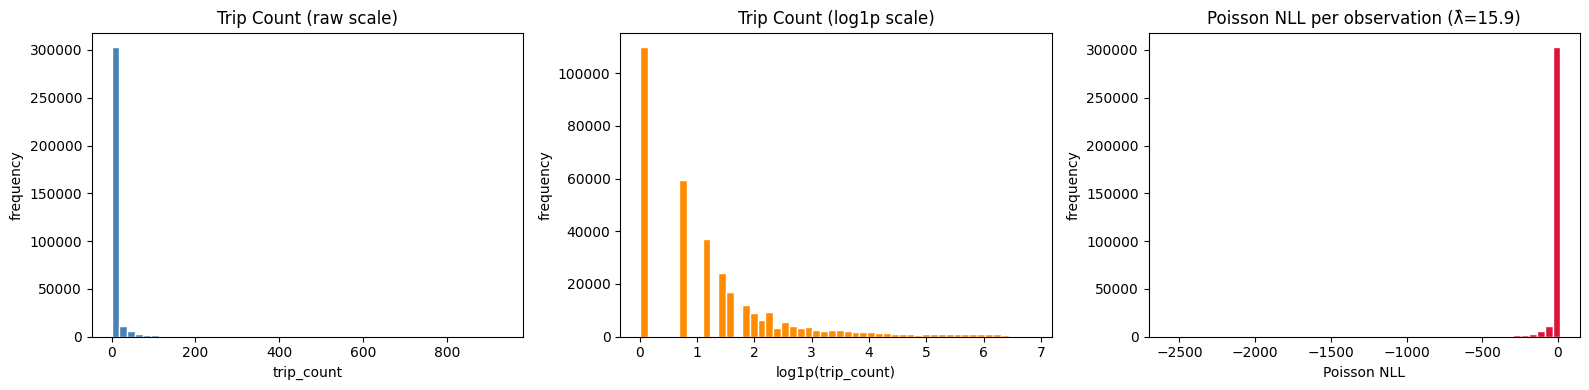

In [160]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Trip Count Distribution   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

y_all       = data[TARGET_COL].values.astype(float)
lambda_hat  = y_all.mean()
dispersion  = y_all.var() / lambda_hat          # >1 indicates overdispersion vs. Poisson

# per-observation Poisson NLL at the fitted rate lambda_hat (up to the constant log(y!) term)
poisson_nll = lambda_hat - y_all * np.log(lambda_hat)

print(f"Empirical mean (lambda_hat) : {lambda_hat:.4f}")
print(f"Empirical variance          : {y_all.var():.4f}")
print(f"Dispersion (var / mean)     : {dispersion:.4f}  ({'overdispersed' if dispersion > 1 else 'underdispersed / Poisson-consistent'})")
print(f"Mean Poisson NLL @ lambda_hat: {poisson_nll.mean():.4f}  (up to const. log(y!))")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_all, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Trip Count (raw scale)")
axes[0].set_xlabel("trip_count")
axes[0].set_ylabel("frequency")

axes[1].hist(np.log1p(y_all), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Trip Count (log1p scale)")
axes[1].set_xlabel("log1p(trip_count)")
axes[1].set_ylabel("frequency")

axes[2].hist(poisson_nll, bins=50, color="crimson", edgecolor="white")
axes[2].set_title(f"Poisson NLL per observation (λ̂={lambda_hat:.1f})")
axes[2].set_xlabel("Poisson NLL")
axes[2].set_ylabel("frequency")

plt.tight_layout()
plt.show()

## 4.2.16 Visualization: Architecture Comparison

Side-by-side comparison of the three **tuned** architectures, aggregated over seeds (mean ± std):

- **left** — train / validation / test loss, all under the training criterion (`config.LOSS`), so the three bars per architecture share one scale and gaps indicate over-/underfitting;
- **right** — test-set MAE on the raw trip-count scale (the headline metric).


Training criterion: nb_nll (raw counts), 1 seed(s)

               train_loss         val_loss        test_loss              mae
Baseline  1.8561 ± 0.0000  1.8879 ± 0.0000  1.8724 ± 0.0000  5.8646 ± 0.0000
Deeper    1.8985 ± 0.0000  1.8666 ± 0.0000  1.8209 ± 0.0000  5.5690 ± 0.0000
Wider     1.8374 ± 0.0000  1.8860 ± 0.0000  1.8850 ± 0.0000  6.0732 ± 0.0000


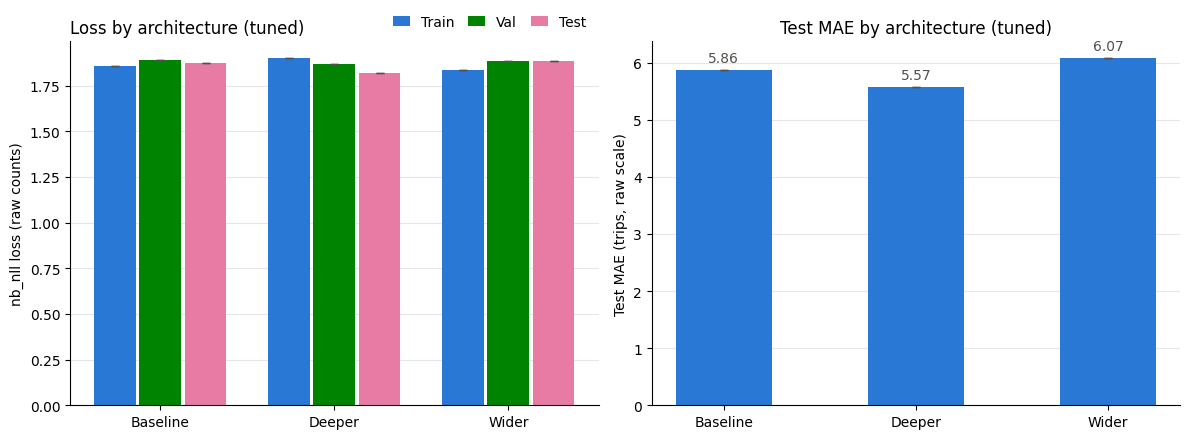

In [161]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Architecture Comparison  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# One figure over the three tuned architectures:
#   left  — train / val / test loss under the training criterion (mean ± std over seeds)
#   right — test-set MAE on the raw trip-count scale (mean ± std over seeds)
# Test loss is computed here with the same criterion as training, so the three
# bars per architecture are directly comparable (matching the overfitting-check
# in evaluate_models, which now also uses the training criterion).

import matplotlib.pyplot as plt

ARCH_RUNS = {
    "Baseline": (tuned_models,        tuned_train_losses,        tuned_val_losses),
    "Deeper":   (tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses),
    "Wider":    (tuned_wider_models,  tuned_wider_train_losses,  tuned_wider_val_losses),
}

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(ca_test, dtype=torch.long).to(device)
_y_target = y_test if IS_POISSON else np.log1p(y_test)   # test target on the training scale

def _test_loss_and_mae(model):
    """Per-seed test loss (training criterion) and raw-scale test MAE."""
    model.eval()
    with torch.no_grad():
        preds_raw = model(_X_test_t, _g_test_t).cpu().numpy().flatten()
    if config.LOSS == "mae":
        test_loss = float(np.mean(np.abs(preds_raw - _y_target)))
    elif config.LOSS == "mse":
        test_loss = float(np.mean((preds_raw - _y_target) ** 2))
    elif config.LOSS == "poisson_nll":
        test_loss = float(np.mean(np.exp(preds_raw) - _y_target * preds_raw))
    else:  # nb_nll — evaluate with the model's trained dispersion
        test_loss = float(nb_nll_loss(torch.as_tensor(preds_raw, dtype=torch.float32),
                                      torch.as_tensor(_y_target, dtype=torch.float32),
                                      model.log_theta.detach().cpu()))
    preds = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    return test_loss, float(np.mean(np.abs(preds - y_test)))

stats = {}
for _label, (_models, _tr, _vl) in ARCH_RUNS.items():
    _per_seed = [_test_loss_and_mae(m) for m in _models]
    stats[_label] = {
        "train_loss": (np.mean(_tr), np.std(_tr)),
        "val_loss":   (np.mean(_vl), np.std(_vl)),
        "test_loss":  (np.mean([t for t, _ in _per_seed]), np.std([t for t, _ in _per_seed])),
        "mae":        (np.mean([m for _, m in _per_seed]), np.std([m for _, m in _per_seed])),
    }

summary_df = pd.DataFrame(
    {a: {k: f"{m:.4f} ± {s:.4f}" for k, (m, s) in d.items()} for a, d in stats.items()}
).T
print(f"Training criterion: {config.LOSS} ({'raw counts' if IS_POISSON else 'log1p scale'}), "
      f"{len(SEEDS)} seed(s)\n")
print(summary_df.to_string())

_archs  = list(stats)
_splits = [("train_loss", "Train", "#2a78d6"),
           ("val_loss",   "Val",   "#008300"),
           ("test_loss",  "Test",  "#e87ba4")]

fig, (ax_loss, ax_mae) = plt.subplots(1, 2, figsize=(12, 4.5))
_x = np.arange(len(_archs))

for _i, (_split, _sl, _c) in enumerate(_splits):
    _means = [stats[a][_split][0] for a in _archs]
    _stds  = [stats[a][_split][1] for a in _archs]
    ax_loss.bar(_x + (_i - 1) * 0.26, _means, width=0.24, color=_c, label=_sl,
                yerr=_stds, capsize=3, error_kw=dict(ecolor="#52514e", lw=1))
ax_loss.set_xticks(_x, _archs)
ax_loss.set_ylabel(f"{config.LOSS} loss ({'raw counts' if IS_POISSON else 'log1p scale'})")
ax_loss.set_title("Loss by architecture (tuned)", loc="left")
ax_loss.legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0),
               ncols=3, handlelength=1.2, columnspacing=1.0)

_means = [stats[a]["mae"][0] for a in _archs]
_stds  = [stats[a]["mae"][1] for a in _archs]
ax_mae.bar(_x, _means, width=0.5, color="#2a78d6",
           yerr=_stds, capsize=3, error_kw=dict(ecolor="#52514e", lw=1))
for _xi, _m, _s in zip(_x, _means, _stds):
    ax_mae.annotate(f"{_m:.2f}", (_xi, _m + _s), ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points", color="#52514e")
ax_mae.set_xticks(_x, _archs)
ax_mae.set_ylabel("Test MAE (trips, raw scale)")
ax_mae.set_title("Test MAE by architecture (tuned)")

for _ax in (ax_loss, ax_mae):
    _ax.grid(axis="y", color="0.90", linewidth=0.8)
    _ax.set_axisbelow(True)
    for _side in ("top", "right"):
        _ax.spines[_side].set_visible(False)

plt.tight_layout()
plt.show()


### Learning Curves

Per-epoch train / validation / test loss for each tuned architecture, all under the training criterion. The dot marks the best-validation epoch whose weights early stopping restores. Requires re-running the tuned training cells once, since `train_model` now records the history on the returned models.


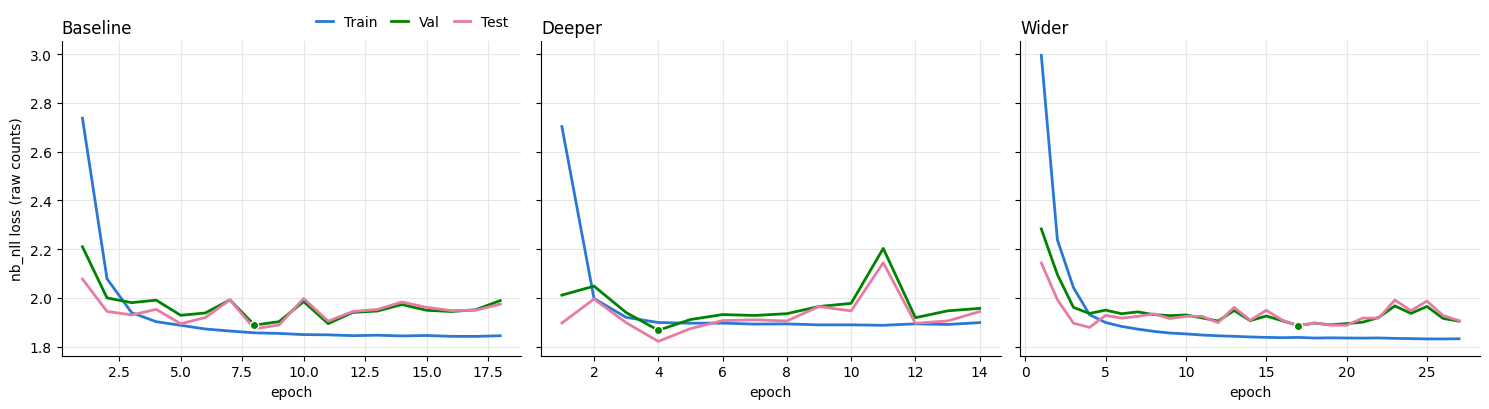

In [162]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Learning Curves          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# Per-epoch train / val / test loss for the three tuned architectures.
# train_model records the history on each returned model; the tuned training
# cells pass test_data so the test curve is monitored per epoch too
# (monitoring only — it never influences training or model selection).

import matplotlib.pyplot as plt

ARCH_CURVES = {
    "Baseline": tuned_models,
    "Deeper":   tuned_deeper_models,
    "Wider":    tuned_wider_models,
}
_colors = {"train": "#2a78d6", "val": "#008300", "test": "#e87ba4"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for _ax, (_label, _models) in zip(axes, ARCH_CURVES.items()):
    for _si, _model in enumerate(_models):
        _h = getattr(_model, "history", None)
        if _h is None:
            raise RuntimeError("model has no training history — re-run the tuned "
                               "training cells (train_model records it now)")
        _epochs = np.arange(1, len(_h["train"]) + 1)
        for _split in ("train", "val", "test"):
            if _h[_split]:
                _ax.plot(_epochs, _h[_split], color=_colors[_split], lw=2,
                         alpha=1.0 if _si == 0 else 0.4,
                         label=_split.capitalize() if _si == 0 else None)
        _best = int(np.argmin(_h["val"]))   # epoch restored by early stopping
        _ax.plot(_best + 1, _h["val"][_best], "o", ms=6, color=_colors["val"],
                 markeredgecolor="white", zorder=3)
    _ax.set_title(_label, loc="left")
    _ax.set_xlabel("epoch")
    _ax.grid(color="0.90", linewidth=0.8)
    _ax.set_axisbelow(True)
    for _side in ("top", "right"):
        _ax.spines[_side].set_visible(False)

axes[0].set_ylabel(f"{config.LOSS} loss ({'raw counts' if IS_POISSON else 'log1p scale'})")
axes[0].legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0),
               ncols=3, handlelength=1.2, columnspacing=1.0)

plt.tight_layout()
plt.show()


### Statistical Significance — Wilcoxon Signed-Rank

Non-parametric paired test of whether each **tuned** network is more accurate than the benchmark models on the held-out test set, using per-row absolute errors (the tuned architectures are seed-ensembled — mean predicted count). Every model scores the same test rows, so the errors are paired. Reported with a Holm-corrected one-sided *p*-value (H1: NN error < benchmark error) and practical effect sizes, since on a test set this large even trivial gaps come out "significant".

This test aims to **identify whether a model adds value, not whether neural networks should be deployed**. If the difference in performance is not statistically significant, the model adds no measurable value over the benchmark. If it is significant, further analysis is needed to determine whether that value justifies the cost.

In [163]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Statistical Significance (Wilcoxon)     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# Wilcoxon signed-rank test: is each tuned NN more accurate than the benchmarks?
# Per-row absolute errors on the held-out test set; the tuned architectures are
# seed-ensembled (mean predicted count). Every model scores the same test rows,
# so the errors are paired. One-sided H1: NN abs-error < benchmark abs-error.
# p-values are Holm-corrected across all comparisons, and because a test set this
# large makes even trivial gaps "significant", the practical effect sizes
# (median abs-error reduction, share of rows the NN wins) are shown alongside.

from scipy.stats import wilcoxon

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(ca_test, dtype=torch.long).to(device)
_y        = np.asarray(y_test, dtype=float)


def _nn_ensemble_preds(models):
    """Seed-ensembled predicted counts (raw trip-count scale) on the test set."""
    acc = np.zeros(len(_y), dtype=float)
    for _m in models:
        _m.eval()
        with torch.no_grad():
            _pr = _m(_X_test_t, _g_test_t).cpu().numpy().flatten()
        acc += np.exp(_pr) if IS_POISSON else np.expm1(_pr)
    return acc / len(models)


nn_preds = {
    "Baseline (tuned)": _nn_ensemble_preds(tuned_models),
    "Deeper (tuned)":   _nn_ensemble_preds(tuned_deeper_models),
    "Wider (tuned)":    _nn_ensemble_preds(tuned_wider_models),
}
benchmark_preds = {
    "Historical mean": np.asarray(hist_mean_preds, dtype=float),
    "Ridge":           np.asarray(ridge_preds,     dtype=float),
}

_rows = []
for _mname, _mpred in nn_preds.items():
    _ae_nn = np.abs(_mpred - _y)
    for _bname, _bpred in benchmark_preds.items():
        _ae_bm = np.abs(_bpred - _y)
        _diff  = _ae_nn - _ae_bm
        _stat, _p = wilcoxon(_ae_nn, _ae_bm, alternative="less", zero_method="wilcox")
        _rows.append({
            "NN model"            : _mname,
            "Benchmark"           : _bname,
            "median AE (NN)"      : float(np.median(_ae_nn)),
            "median AE (bench)"   : float(np.median(_ae_bm)),
            "median AE reduction" : float(np.median(_ae_bm) - np.median(_ae_nn)),
            "NN wins %"           : float(100.0 * np.mean(_ae_nn < _ae_bm)),
            "W"                   : float(_stat),
            "p (one-sided)"       : float(_p),
            "n (non-tied)"        : int(np.sum(_diff != 0)),
        })

sig_df = pd.DataFrame(_rows)

# Holm-Bonferroni step-down correction across all comparisons
_pv  = sig_df["p (one-sided)"].to_numpy()
_ord = np.argsort(_pv)
_adj = np.empty_like(_pv)
_run = 0.0
for _rank, _idx in enumerate(_ord):
    _run = max(_run, (len(_pv) - _rank) * _pv[_idx])
    _adj[_idx] = min(_run, 1.0)
sig_df["p (Holm)"]    = _adj
sig_df["significant"] = sig_df["p (Holm)"] < 0.05

print("Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks")
print(f"paired over {len(_y):,} test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05\n")
with pd.option_context("display.width", 200, "display.max_columns", None,
                       "display.float_format", lambda v: f"{v:.4g}"):
    print(sig_df.to_string(index=False))


Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks
paired over 50,589 test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05

        NN model       Benchmark  median AE (NN)  median AE (bench)  median AE reduction  NN wins %         W  p (one-sided)  n (non-tied)   p (Holm)  significant
Baseline (tuned) Historical mean          0.8562             0.9375              0.08131      51.36 5.609e+08     5.157e-128         50589 5.157e-128         True
Baseline (tuned)           Ridge          0.8562              3.189                2.333      64.83 2.583e+08              0         50589          0         True
  Deeper (tuned) Historical mean          0.7872             0.9375               0.1503       56.2 4.893e+08              0         50589          0         True
  Deeper (tuned)           Ridge          0.7872              3.189                2.402      65.66 2.513e+08              0         50589          0         True
   Wider (tuned) Historical mean     